# Random Forest

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/Gaming_and_Mental_Health.csv")

In [3]:
df.columns.tolist()

['record_id',
 'age',
 'gender',
 'daily_gaming_hours',
 'game_genre',
 'primary_game',
 'gaming_platform',
 'sleep_hours',
 'sleep_quality',
 'sleep_disruption_frequency',
 'academic_work_performance',
 'grades_gpa',
 'work_productivity_score',
 'mood_state',
 'mood_swing_frequency',
 'withdrawal_symptoms',
 'loss_of_other_interests',
 'continued_despite_problems',
 'eye_strain',
 'back_neck_pain',
 'weight_change_kg',
 'exercise_hours_weekly',
 'social_isolation_score',
 'face_to_face_social_hours_weekly',
 'monthly_game_spending_usd',
 'years_gaming',
 'gaming_addiction_risk_level']

## Test 1
Random Forest with target_3 as target and selected features.

### Target

In [4]:
target = "academic_work_performance"

mapping = {
    "Failing": "Low",
    "Poor": "Low",
    "Below Average": "Medium",
    "Average": "Medium",
    "Good": "High",
    "Excellent": "High",
}

In [5]:
df["target_3"] = df["academic_work_performance"].map(mapping)

In [6]:
target = "target_3"

### Features

In [7]:
selected_features = [
    "age",
    "gender",
    "daily_gaming_hours",
    "game_genre",
    "primary_game",
    "gaming_platform",
    "monthly_game_spending_usd",
    "years_gaming",
    "gaming_addiction_risk_level",    
]

In [8]:
def audit_column(df, col, target="academic_work_performance"):
    print(f"\n{'='*70}")
    print(f"Column: {col}")
    print(f"{'='*70}")
    print("dtype:", df[col].dtype)
    print("missing:", df[col].isnull().sum())
    print("unique:", df[col].nunique())

    if pd.api.types.is_numeric_dtype(df[col]):
        print("\nsummary:")
        print(df[col].describe())
    else:
        print("\ntop values:")
        print(df[col].value_counts(dropna=False).head(15))

    print("\nvs target:")
    if pd.api.types.is_numeric_dtype(df[col]):
        print(df.groupby(target)[col].describe()[["mean", "std", "min", "max"]])
    else:
        print(pd.crosstab(df[col], df[target], normalize="index").head(15))

for col in selected_features:
    audit_column(df, col, target)


Column: age
dtype: int64
missing: 0
unique: 23

summary:
count    1000.000000
mean       20.475000
std         4.116105
min        13.000000
25%        18.000000
50%        20.000000
75%        22.000000
max        35.000000
Name: age, dtype: float64

vs target:
               mean       std   min   max
target_3                                 
High      20.429603  4.188440  13.0  34.0
Low       20.585366  3.813888  14.0  35.0
Medium    20.444444  4.229691  13.0  35.0

Column: gender
dtype: str
missing: 0
unique: 3

top values:
gender
Male      647
Female    331
Other      22
Name: count, dtype: int64

vs target:
target_3      High       Low    Medium
gender                                
Female    0.280967  0.229607  0.489426
Male      0.276662  0.258114  0.465224
Other     0.227273  0.136364  0.636364

Column: daily_gaming_hours
dtype: float64
missing: 0
unique: 132

summary:
count    1000.000000
mean        6.151400
std         2.867194
min         0.500000
25%         4.100000
50

### Training

In [9]:
# Features
selected_features = [
    "age",
    "gender",
    "daily_gaming_hours",
    "game_genre",
    "primary_game",
    "gaming_platform",
    "monthly_game_spending_usd",
    "years_gaming",
    "gaming_addiction_risk_level",
]


# Target
mapping = {
    "Failing": "Low",
    "Poor": "Low",
    "Below Average": "Medium",
    "Average": "Medium",
    "Good": "High",
    "Excellent": "High",
}

df["target_3"] = df["academic_work_performance"].map(mapping)

target = "target_3"

df_model = df[selected_features + [target]].copy()

# Cat x Num split
categorical_cols = [
    "gender",
    "game_genre",
    "primary_game",
    "gaming_platform",
    "gaming_addiction_risk_level",
]

numeric_cols = [
    "age",
    "daily_gaming_hours",
    "monthly_game_spending_usd",
    "years_gaming",
]

# Model
df_model = df[selected_features + [target]].copy()

In [10]:
X = df_model[selected_features]
y = df_model[target]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

In [13]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [14]:
y_pred = pipeline.predict(X_test)

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print()
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.47
Precision: 0.4689
Recall   : 0.47
F1-score : 0.4634

              precision    recall  f1-score   support

        High       0.44      0.31      0.36        55
         Low       0.51      0.45      0.48        49
      Medium       0.47      0.57      0.51        96

    accuracy                           0.47       200
   macro avg       0.47      0.44      0.45       200
weighted avg       0.47      0.47      0.46       200



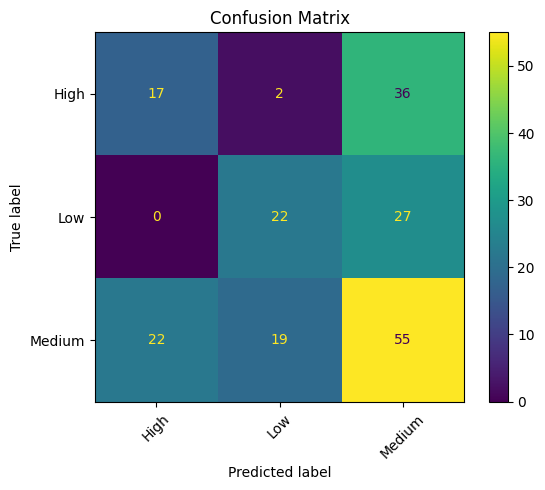

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

In [17]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

importance_df.head(15)

,feature,importance
43,num__daily_gaming_hours,0.204167
44,num__monthly_game_spending_usd,0.150271
42,num__age,0.092768
45,num__years_gaming,0.088699
39,cat__gaming_addiction_risk_level_Low,0.043056
36,cat__gaming_platform_Multi-platform,0.020414
34,cat__gaming_platform_Console,0.020204
37,cat__gaming_platform_PC,0.019752
1,cat__gender_Male,0.019344
0,cat__gender_Female,0.019160


## Test 2
Random Forest with all classes of target and all features.

removed features ->
    "record_id",
    "grades_gpa",
    "work_productivity_score",

In [18]:
selected_features_all = [
    "age",
    "gender",
    "daily_gaming_hours",
    "game_genre",
    "primary_game",
    "gaming_platform",
    "sleep_hours",
    "sleep_quality",
    "sleep_disruption_frequency",
    "mood_state",
    "mood_swing_frequency",
    "withdrawal_symptoms",
    "loss_of_other_interests",
    "continued_despite_problems",
    "eye_strain",
    "back_neck_pain",
    "weight_change_kg",
    "exercise_hours_weekly",
    "social_isolation_score",
    "face_to_face_social_hours_weekly",
    "monthly_game_spending_usd",
    "years_gaming",
    "gaming_addiction_risk_level",
]

target = "academic_work_performance"

df_model = df[selected_features_all + [target]].copy()

In [19]:
X = df_model[selected_features_all]
y = df_model[target]

categorical_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()



In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

In [22]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [23]:
y_pred = pipeline.predict(X_test)

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.33
Precision: 0.3693500575043128
Recall   : 0.33
F1-score : 0.31577413570643104

Classification Report:

               precision    recall  f1-score   support

      Average       0.34      0.51      0.41        49
Below Average       0.23      0.24      0.24        46
    Excellent       0.30      0.14      0.19        21
      Failing       1.00      0.08      0.14        13
         Good       0.39      0.31      0.35        35
         Poor       0.38      0.42      0.39        36

     accuracy                           0.33       200
    macro avg       0.44      0.28      0.29       200
 weighted avg       0.37      0.33      0.32       200



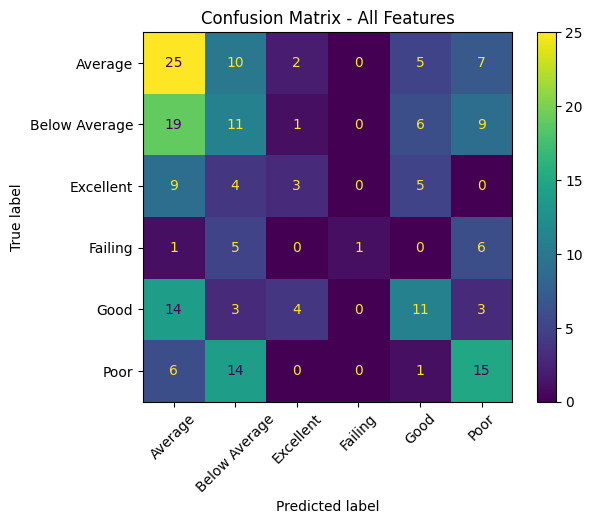

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Confusion Matrix - All Features")
plt.show()

In [26]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

importance_df.head(15)

,feature,importance
67,num__daily_gaming_hours,0.078294
72,num__face_to_face_social_hours_weekly,0.067494
68,num__sleep_hours,0.064367
73,num__monthly_game_spending_usd,0.063831
70,num__exercise_hours_weekly,0.062292
69,num__weight_change_kg,0.054509
66,num__age,0.048483
74,num__years_gaming,0.043293
71,num__social_isolation_score,0.042088
63,cat__gaming_addiction_risk_level_Low,0.014989


## Test 3
All features but target_3 as target.

In [27]:
selected_features_all = [
    "age",
    "gender",
    "daily_gaming_hours",
    "game_genre",
    "primary_game",
    "gaming_platform",
    "sleep_hours",
    "sleep_quality",
    "sleep_disruption_frequency",
    "mood_state",
    "mood_swing_frequency",
    "withdrawal_symptoms",
    "loss_of_other_interests",
    "continued_despite_problems",
    "eye_strain",
    "back_neck_pain",
    "weight_change_kg",
    "exercise_hours_weekly",
    "social_isolation_score",
    "face_to_face_social_hours_weekly",
    "monthly_game_spending_usd",
    "years_gaming",
    "gaming_addiction_risk_level",
]

mapping = {
    "Failing": "Low",
    "Poor": "Low",
    "Below Average": "Medium",
    "Average": "Medium",
    "Good": "High",
    "Excellent": "High",
}

df["target_3"] = df["academic_work_performance"].map(mapping)

target = "target_3"

X = df_model[selected_features_all]
y = df_model[target]

df_model = df[selected_features_all + [target]].copy()

categorical_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

KeyError: 'target_3'

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

In [ ]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted", zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, average="weighted", zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, average="weighted", zero_division=0))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.545
Precision: 0.5558327081770442
Recall   : 0.545
F1-score : 0.5364239130434783

Classification Report:

              precision    recall  f1-score   support

        High       0.64      0.38      0.48        55
         Low       0.51      0.45      0.48        49
      Medium       0.53      0.69      0.60        96

    accuracy                           0.55       200
   macro avg       0.56      0.51      0.52       200
weighted avg       0.56      0.55      0.54       200



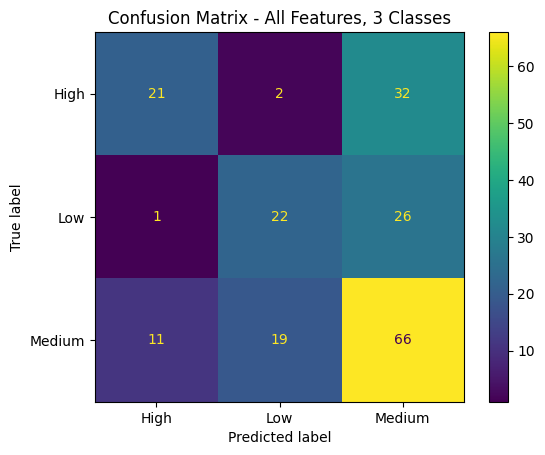

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix - All Features, 3 Classes")
plt.show()

In [ ]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

importance_df.head(15)

,feature,importance
67,num__daily_gaming_hours,0.101291
72,num__face_to_face_social_hours_weekly,0.080264
68,num__sleep_hours,0.074339
73,num__monthly_game_spending_usd,0.068016
70,num__exercise_hours_weekly,0.060508
71,num__social_isolation_score,0.048682
69,num__weight_change_kg,0.048320
66,num__age,0.044361
74,num__years_gaming,0.038178
63,cat__gaming_addiction_risk_level_Low,0.021924
